# Model Training and Evaluation

This notebook is based on the `train_opt.py` script and is used for model training and evaluation. The original script's `Optuna` hyperparameter optimization feature has been removed, and instead, a set of pre-defined optimal parameters is used directly for training.

## Import Required Libraries
First, we import all necessary Python libraries, including `torch`, `pandas`, `numpy`, and project-specific utility modules.

In [2]:
import torch
import pandas as pd
import numpy as np
import os
import itertools
from torch.utils.data import TensorDataset, DataLoader

# 导入项目自定义模块
from models import model
from utils import opt_utils, args_utils
from data_loaders import domain_loaders
import seaborn as sns
import matplotlib.pyplot as plt

## Parameter Settings
In this cell, set all the parameters required for training. Please fill in your known best hyperparameters at the `TODO` mark.

In [ ]:
from argparse import Namespace
import os

# 1. Manually create args object
# In Jupyter, we use Namespace to create an empty object instead of command-line parsing
args = Namespace()

# --- TODO: Fill in the best hyperparameters ---
args.lr = 0.005  # Learning rate
args.dropout = 0.1 # Dropout rate
args.weight_decay = 1e-5 # Weight decay
args.batch_size = 256    # Batch size
# --------------------------------
args.train_dir="/mnt/nvme/extra_data/wujialu/scFM-Bench/output/TISCH"
args.val_dir="/mnt/nvme/extra_data/wujialu/scFM-Bench/output/TISCH"
args.val_domain="Bone"
args.input_features="xTrimoGene"
args.max_epoch=200
args.patience=20
args.label_str="label"
args.gpu_id=0
args.NEED_ROWS=20000
args.gene_num=5000

args.output="optuna_results"
args.seed = 0
args.schuse = False            # Whether to use learning rate scheduler (action='store_true')
args.schusech = 'cos'          # Type of scheduler to use
args.num_classes = 1           # Number of classes
args.momentum = 0.9            # Optimizer momentum
args.lr_decay = 0.75           # Learning rate decay
args.lr_decay1 = 1.0           # Pretrained feature extractor learning rate decay
args.lr_decay2 = 1.0           # Initial learning rate decay
args.anneal_iters = 500        # VREx penalty anneal iters
args.genelist_outname = 'gene_list.txt' # Gene list output filename
args.logs_name = 'train_log'   # Training log name
args.lam = 1.0                 # VREx trade-off hyperparameter
args.HVG_list, domains = opt_utils.generate_genelist(args)
# Set output directory based on parameter configuration
args.output = os.path.join(args.output, args.input_features, f"bs_{args.batch_size}_lr_{args.lr}_drop_{args.dropout:.2f}_decay_{args.weight_decay}")
os.makedirs(args.output, exist_ok=True)
print(f"All output files will be saved in: {args.output}")

# Set random seed for reproducibility
args_utils.set_random_seed(args.seed)

所有输出文件将保存在: optuna_results/xTrimoGene/bs_256_lr_0.005_drop_0.10_decay_1e-05


## 3. Core Training Function

The function `main(args)` encapsulates the complete training and evaluation workflow, including:
- Loading training and validation datasets
- Initializing the model, optimizer, and scheduler
- Iteratively training for all epochs
- Evaluating the model at the end of each epoch
- Saving the best-performing model and prediction results

In [ ]:
def main(args):
    """
    Complete training and evaluation workflow for single-domain validation.
    """
    # 1. Load data loaders
    train_loaders, feature_dim = domain_loaders.train_domain_loaders_l(args)
    args.feature_dim = feature_dim
    print(f"Loaded data from {len(train_loaders)} domains for training.")
    val_loaders = domain_loaders.val_domain_loaders_l(args)

    # 2. Create log files for recording loss and validation results
    output_dir = os.path.join(args.output, args.val_domain)
    os.makedirs(output_dir, exist_ok=True)
    f_loss_io = open(os.path.join(output_dir, f'{args.logs_name}_loss.txt'), 'w')
    f_val_io = open(os.path.join(output_dir, f'{args.logs_name}_val.txt'), 'w')
    
    # Write header for validation log
    header = '\t'.join(val_loaders.keys())
    print(header, file=f_val_io)
    print(f"Acc\t    AUROC\tAUPRC", file=f_val_io)

    # 3. Initialize model, optimizer, and scheduler
    algorithm = model.VREx(args)
    opt = opt_utils.get_optimizer(algorithm, args)
    sch = opt_utils.get_scheduler(opt, args)

    # 4. Start training loop
    best_metrics = {"auroc": 0.}
    early_stop = 0
    y_pred_best = []

    for epoch in range(args.max_epoch):
        # Switch to training mode
        count = 0 
        for single_train_minibatches in zip(*train_loaders): 
            count += 1
            algorithm.train()
            if args.gpu_id is not None:
                algorithm.cuda()
            minibatches_device = [(data) for data in single_train_minibatches if data is not None]      
            # back-propagation
            step_vals = algorithm.update(minibatches_device, opt, sch)
            print(step_vals, file=f_loss_io)
        algorithm.eval()

        # 5. Evaluate model on validation set
        print(f'Epoch={epoch}:', end='\t')
        val_results_line = []
        current_auroc = 0
        
        for loader_name, loader in val_loaders.items():
            acc, auroc, auprc, y_true, y_pred = opt_utils.evaluate(algorithm, loader)
            val_results_line.append(f'{acc:.4f}\t{auroc:.4f}\t{auprc:.4f}')
            print(f'{loader_name} AUROC: {auroc:.4f}', end='\t')
            
            # We only care about the performance on the validation domain (val_domain) for model selection
            if loader_name == args.val_domain:
                current_auroc = auroc
                current_acc = acc
                current_auprc = auprc
                current_y_pred = y_pred
                current_y_true = y_true

        print('\t'.join(val_results_line), file=f_val_io)
        f_val_io.flush()
        print()

        # 6. Save best model (Early Stopping)
        if current_auroc > best_metrics["auroc"]:
            best_metrics["auroc"] = current_auroc
            best_metrics["acc"] = current_acc
            best_metrics["auprc"] = current_auprc
            y_pred_best = current_y_pred
            opt_utils.save_checkpoint(f'model_best.pkl', algorithm, args)
            print(f'*** New best model saved with AUROC: {current_auroc:.4f} ***')
            early_stop = 0
        else:
            early_stop += 1
        
        if early_stop > args.patience:
            print(f"Early stopping triggered after {args.patience} epochs without improvement.")
            break

    # 7. Save final results
    print(f'\nBest result on {args.val_domain}:\n Acc: {best_metrics["acc"]:.4f}\n AUROC: {best_metrics["auroc"]:.4f}\n AUPRC: {best_metrics["auprc"]:.4f}', file=f_val_io)
    f_val_io.flush()
    
    # Save predictions and true labels
    pred_df = pd.DataFrame()
    pred_df["y_true"] = current_y_true # Use true labels from the last epoch
    pred_df["y_pred"] = y_pred_best
    pred_df.to_csv(os.path.join(output_dir, "predictions.csv"), index=False)

    f_val_io.close()
    f_loss_io.close()

    return best_metrics


## 4. Execute Training Workflow

This is the main entry point of the script. It will:
1. Generate the gene list and domain list.
2. Iterate over each domain, using it as the validation set and the others as the training set.
3. Call the `main` function to perform training.
4. Collect and print the average performance across all cross-validation folds.

In [ ]:
if __name__ == "__main__":
    # 1. Generate gene list and all available domains
    HVG_list, domains = opt_utils.generate_genelist(args)

    # 2. Loop through each domain for leave-one-domain-out cross-validation
    best_auroc_ls = []
    print(f"Starting training process, validating on each domain: {domains}")
    print("-" * 50)

    for domain in domains:
        print(f"\nVALIDATING ON DOMAIN: {domain}")
        val_domain = domain
        
        # Call the main function for training and evaluation
        best_metrics = main(args)
        best_auroc_ls.append(best_metrics["auroc"])
        print(f"Finished validation on {domain}. Best AUROC: {best_metrics['auroc']:.4f}")
        print("-" * 50)

    # 3. Print final average performance
    mean_auroc = np.mean(best_auroc_ls)
    print(f"\n\nCross-validation finished.")
    print(f"Individual AUROC scores: {best_auroc_ls}")
    print(f"Mean AUROC across all domains: {mean_auroc:.4f}")

Starting training process, validating on each domain: ['Blood', 'Bone', 'Brain', 'Eye']
--------------------------------------------------

VALIDATING ON DOMAIN: Blood
从 3 个域加载数据进行训练。
{'Bone': <torch.utils.data.dataloader.DataLoader object at 0x7f6dcbfc5760>}
Epoch=0:	Bone AUROC: 0.6398	
*** New best model saved with AUROC: 0.6398 ***
Epoch=1:	Bone AUROC: 0.6939	
*** New best model saved with AUROC: 0.6939 ***
Epoch=2:	Bone AUROC: 0.7069	
*** New best model saved with AUROC: 0.7069 ***
Epoch=3:	Bone AUROC: 0.7052	
Epoch=4:	Bone AUROC: 0.7008	
Epoch=5:	Bone AUROC: 0.6921	
Epoch=6:	Bone AUROC: 0.6891	
Epoch=7:	Bone AUROC: 0.6811	
Epoch=8:	Bone AUROC: 0.6737	
Epoch=9:	Bone AUROC: 0.6706	
Epoch=10:	Bone AUROC: 0.6602	
Epoch=11:	Bone AUROC: 0.6648	
Epoch=12:	Bone AUROC: 0.6530	
Epoch=13:	Bone AUROC: 0.6377	
Epoch=14:	Bone AUROC: 0.6542	
Epoch=15:	Bone AUROC: 0.6420	
Epoch=16:	Bone AUROC: 0.6428	
Epoch=17:	Bone AUROC: 0.6384	
Epoch=18:	Bone AUROC: 0.6131	
Epoch=19:	Bone AUROC: 0.6301	
Epoch=

## 5. Results Visualization

The following cells demonstrate how to visualize the model evaluation results. We first construct a summary DataFrame containing the AUROC and AUPRC scores for the current validation domain. Then, we use Seaborn to generate bar plots for each metric, providing a clear comparison of model performance across tissues. Custom color palettes and shapes are used for consistent and informative visualization.

In [22]:
# load optimized results

model_map_dict = {"X_geneformer": "Geneformer",
                  "X_langcell": "LangCell",
                  "X_scgpt": "scGPT",
                  "X_uce": "UCE",
                  "X_xtrimogene": "scFoundation",
                  "X_hvg": "HVG",
                  "X_scvi": "scVI",
                  "X_sccello": "scCello",
                  "X_harmony": "Harmony",
                  "X_seurat_cca": "Seurat_v5(CCA)",
                  "xTrimoGene": "scFoundation",
                  "Seurat_cca": "Seurat_v5(CCA)",
                  "LR_OvR": "LR(OvR)",
                  "X": "Raw",
                  "scVI_integrated_tissue": "scVI",
                  "scVI_integrated_dataset": "scVI"}

model_order_baseline = ["scVI", "Harmony", "Seurat_v5(CCA)"]
model_order_scFM = ["Geneformer", "scGPT", "UCE", "scFoundation", "LangCell", "scCello"]
model_order_wo_hvg = model_order_baseline + model_order_scFM
model_order = ["HVG"] + model_order_wo_hvg
colors = ["#999999", "#D6D6D6", "#E6CECF", "#A8CFC1", "#E89DA0", "#88CEE6", "#F6C8A8", "#B696B6", "#9FBA95", "#F2E1A7"]
custom_palette = {model: color for model, color in zip(model_order, colors[:len(model_order)])}
custom_palette["Raw"] = custom_palette["HVG"]
custom_palette["LR(OvR)"] = custom_palette["HVG"]
# shapes = ["o", "s", "p", "*", "^", "P", "X"]
shapes = ["h", "v", "D", "H", "o", "s", "p", "*", "^", "d"]
custom_shape = {model: shape for model, shape in zip(model_order, shapes[:len(model_order)])}
custom_shape["Raw"] = custom_shape["HVG"]
custom_shape["LR(OvR)"] = custom_shape["HVG"]

def barplot_with_text(data, metric, **kwargs):
    order = ["Raw", "scVI"] + model_order_scFM
    sns.barplot(data=data, x=metric, y="Model", hue="Model", 
                palette=custom_palette, order=order, orient="h", **kwargs)
    
    min_val = data[metric].min()
    max_val = data[metric].max()
    margin = 0.03
    plt.xlim(min_val - margin, max_val + margin)
    
    for index, model in enumerate(order):
        if model in data["Model"].values:
            value = data.set_index("Model").loc[model, metric]
            plt.text(value+0.005, index, f'{value:.3f}', ha='left', va='center', fontsize=8)
    if "Raw" in data["Model"].values:
        # 添加 Raw 模型的参考线
        plt.axvline(x=data.set_index("Model").loc["Raw", metric], color="red", linestyle=':', alpha=0.8)

In [20]:
df = pd.DataFrame()
df.loc[0, "Model"] = model_map_dict[args.input_features]
df.loc[0, "AUROC"] = best_metrics["auroc"]
df.loc[0, "AUPRC"] = best_metrics["auprc"]
df.loc[0, "Tissue"] = args.val_domain
df

,Model,AUROC,AUPRC,Tissue
0,scFoundation,0.717245,0.787822,Bone


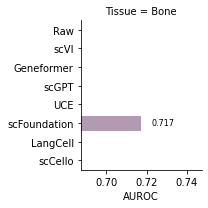

In [ ]:
%matplotlib inline
metric = "AUROC"
grid = sns.FacetGrid(df, col="Tissue", sharex=False, sharey=True)
grid.map_dataframe(barplot_with_text, metric=metric) 
grid.set_axis_labels(metric, "")
plt.tight_layout()
plt.show()

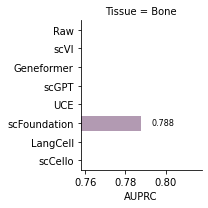

In [25]:
%matplotlib inline
metric = "AUPRC"
grid = sns.FacetGrid(df, col="Tissue", sharex=False, sharey=True)
grid.map_dataframe(barplot_with_text, metric=metric) 
grid.set_axis_labels(metric, "")
plt.tight_layout()
plt.show()